# Task 1: Data Analysis and Visualization

In this task, I will explore the housing dataset to uncover trends, patterns, and key 
factors that influence `SalePrice` (the target). The analysis covers missing value handling, 
distribution analysis, correlation analysis, and neighborhood and time-based trends, 
all visualized and explained in a way that is accessible to non-technical stakeholders.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [69]:
#Load the dataset
df = pd.read_csv('housing_data_900.csv')

In [70]:
#First look at the data
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1001,527131110,120,RL,45.0,6264,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,247900
1,1002,527140090,120,RL,41.0,5395,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,10,2008,WD,Normal,180000
2,1003,527145090,120,RL,39.0,5070,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,180000
3,1004,527161010,60,RL,100.0,10839,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,181000
4,1005,527162180,60,RL,73.0,11184,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2008,WD,Family,183000


In [71]:
#Check how many rows and columns
df.shape

(900, 82)

In [72]:
#Checking the data types and if there are any missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            900 non-null    int64  
 1   PID              900 non-null    int64  
 2   MS SubClass      900 non-null    int64  
 3   MS Zoning        900 non-null    str    
 4   Lot Frontage     734 non-null    float64
 5   Lot Area         900 non-null    int64  
 6   Street           900 non-null    str    
 7   Alley            65 non-null     str    
 8   Lot Shape        900 non-null    str    
 9   Land Contour     900 non-null    str    
 10  Utilities        900 non-null    str    
 11  Lot Config       900 non-null    str    
 12  Land Slope       900 non-null    str    
 13  Neighborhood     900 non-null    str    
 14  Condition 1      900 non-null    str    
 15  Condition 2      900 non-null    str    
 16  Bldg Type        900 non-null    str    
 17  House Style      900 non-nu

In [73]:
#Checking for missing values
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      166
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

#### - We notice that there are missing values, especially for the `Lot Frontage` feature.
#### - We will first examine the number of raw missing values per feature, then analyze missing value percentages to better assess the severity relative to our dataset size.

In [74]:
#Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

Pool QC           99.555556
Misc Feature      96.333333
Alley             92.777778
Fence             83.555556
Mas Vnr Type      55.222222
Fireplace Qu      46.333333
Lot Frontage      18.444444
Garage Cond        4.888889
Garage Yr Blt      4.888889
Garage Qual        4.888889
Garage Finish      4.888889
Garage Type        4.777778
Bsmt Exposure      2.444444
Bsmt Qual          2.333333
BsmtFin Type 2     2.333333
Bsmt Cond          2.333333
BsmtFin Type 1     2.333333
Mas Vnr Area       1.333333
Bsmt Half Bath     0.222222
Bsmt Full Bath     0.222222
BsmtFin SF 1       0.111111
Electrical         0.111111
BsmtFin SF 2       0.111111
Bsmt Unf SF        0.111111
Total Bsmt SF      0.111111
dtype: float64

- By taking a closer look at the missing values, it was understood that the columns `Pool QC`, `Misc Feature`, `Alley` and `Fence` contain a very high percentage of missing data (above 80%). These features are very rare in the dataset and therefore provide limited value for analysis or modeling. 
As a result, we'll drop these columns.

In [75]:
#Drop columns with extremely high missing values
cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']
df = df.drop(columns = cols_to_drop)

In [76]:
#Checking the shape after dropping
df.shape

(900, 78)

In [77]:
df["Fireplace Qu"].value_counts()

Fireplace Qu
Gd    249
TA    181
Fa     23
Ex     17
Po     13
Name: count, dtype: int64

In [78]:
df["Mas Vnr Type"].value_counts()

Mas Vnr Type
BrkFace    311
Stone       85
BrkCmn       7
Name: count, dtype: int64

### High Missing Value Features (~40–55%) – Categorical

The columns `Mas Vnr Type` and `Fireplace Qu` have a substantial number of missing values.
For analysis purposes, we will fill missing values with `"None"` to clearly indicate the absence of the feature.

In [79]:
#Fill categorical missing values with 'None'
categorical_absence = ['Mas Vnr Type', 'Fireplace Qu']

#Looping to fill the missing values in the specified columns
for col in categorical_absence:
    df[col] = df[col].fillna('None')

In [80]:
#Checking if they're filled
df[categorical_absence].isnull().sum()

Mas Vnr Type    0
Fireplace Qu    0
dtype: int64

### Missing values- Numeric Feature: Lot Frontage ~18%

The `Lot Frontage` column has ~18% missing values.  
This feature represents the linear feet of street connected to the property.  
Dropping these rows would remove too many observations, so we will impute missing values.

A reasonable approach is to use the **median Lot Frontage**, potentially grouped by `Neighborhood` to preserve local patterns.  

For simplicity in this analysis, we will fill missing values with the **overall median**, which is robust to outliers.

In [81]:
#Fill numerical missing values with the medianS
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [82]:
#Checking if filled
df["Lot Frontage"].isnull().sum()

np.int64(0)

### Handling Remaining Missing Values
To be sure that our dataset is now ready for modeling without losing rows, we will apply specific imputation strategies depending on the type of features we have:

Categorical Features: For Garage and Basement text columns, NaN represents the absence of the feature. These were filled with 'None'.

Numerical Features: For area and count columns (e.g., Mas Vnr Area, Total Bsmt SF), NaN indicates a value of 0.

Mode Imputation: For the Electrical column, the rare missing values (0.11%) were filled with the most frequent value (Mode).

In [83]:
# 1. Fill Categorical Basement/Garage/Masonry nulls with 'None'
cat_cols = [
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2'
]
df[cat_cols] = df[cat_cols].fillna('None')


In [84]:
# 2. Fill Numerical Basement/Garage/Masonry nulls with 0
num_cols = [
    'Garage Yr Blt', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 
    'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath'
]
df[num_cols] = df[num_cols].fillna(0)

In [85]:
# 3. Handle the 'Electrical' outlier (only 0.11% missing)
#Since every house must have electricity, we fill with the most common value (Mode)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [86]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [87]:
#Statistical summary of the data
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,900.000000,9.000000e+02,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,...,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1450.500000,6.681190e+08,59.411111,70.064444,10098.395556,6.340000,5.583333,1976.127778,1987.368889,121.622222,...,93.808889,52.184444,17.794444,2.502222,16.016667,1.950000,66.100000,6.397778,2007.678889,192203.651111
std,259.951919,1.820221e+08,43.327117,23.407220,7542.998413,1.396786,1.066608,29.109098,19.795493,197.585164,...,116.215591,69.087291,52.406376,24.387970,57.849242,31.420128,666.824036,2.787944,0.467163,85313.945606
min,1001.000000,5.263521e+08,20.000000,21.000000,1477.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2007.000000,13100.000000
25%,1225.750000,5.282352e+08,20.000000,60.000000,7466.500000,5.000000,5.000000,1959.000000,1971.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,136375.000000
50%,1450.500000,5.341751e+08,60.000000,70.000000,9522.500000,6.000000,5.000000,1978.000000,1996.000000,0.000000,...,26.500000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,174000.000000
75%,1675.250000,9.052001e+08,75.000000,80.000000,11695.500000,7.000000,6.000000,2003.000000,2004.000000,196.250000,...,168.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2008.000000,226712.500000
max,1900.000000,1.007100e+09,190.000000,313.000000,164660.000000,10.000000,9.000000,2008.000000,2008.000000,1600.000000,...,736.000000,547.000000,301.000000,407.000000,576.000000,576.000000,15500.000000,12.000000,2008.000000,755000.000000


## Statistical Summary Observations

The target variable `SalePrice` shows a wide range and a right-skewed distribution,
with the mean higher than the median and several high-value outliers.

Many numerical features contain a large number of zero values, indicating optional
house features such as porches, decks, or pools that are absent in most properties.

Additionally, features exist on very different scales, which suggests that feature
scaling will be important during the modeling phase.

# Visualizations

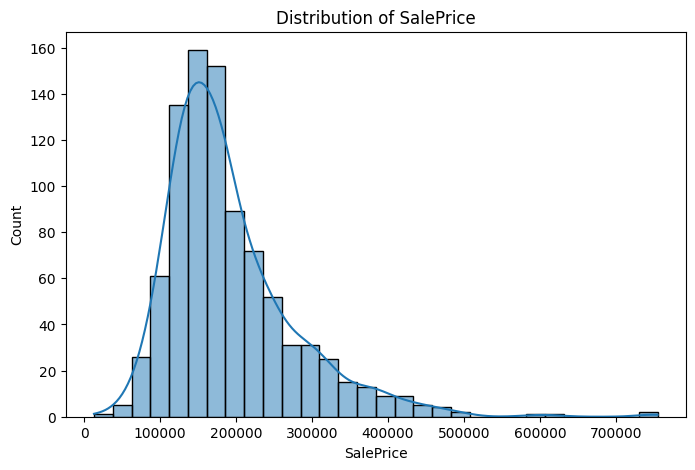

In [88]:
#Distribution of the target variable 'SalePrice'
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('Distribution of SalePrice')
plt.show()

- The distribution of `SalePrice` is positively skewed, with a long right tail. This indicates the presence of higher-priced outliers. To stabilize variance and improve model performance, a log transformation of the target variable may be beneficial during modeling.

- Most houses are clustered between roughly 100k–250k.

In [89]:
#To confirm the skewness of the target variable
df['SalePrice'].skew()

np.float64(1.7531526477418506)

In [90]:
# Applying log transformation to reduce skewness
df['SalePrice_log'] = np.log1p(df['SalePrice'])

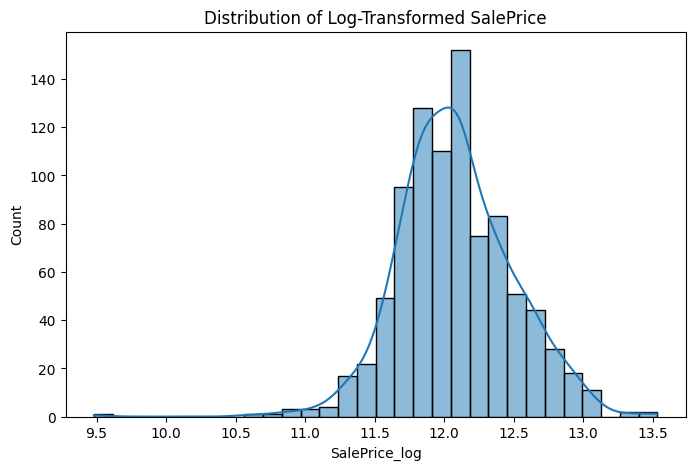

In [91]:
#Distribution of the log-transformed target variable 'SalePrice_log'
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice_log'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed SalePrice')
plt.show()

- Log-transforming the target helps linear models capture relationships more effectively and reduces the influence of extreme sale prices.

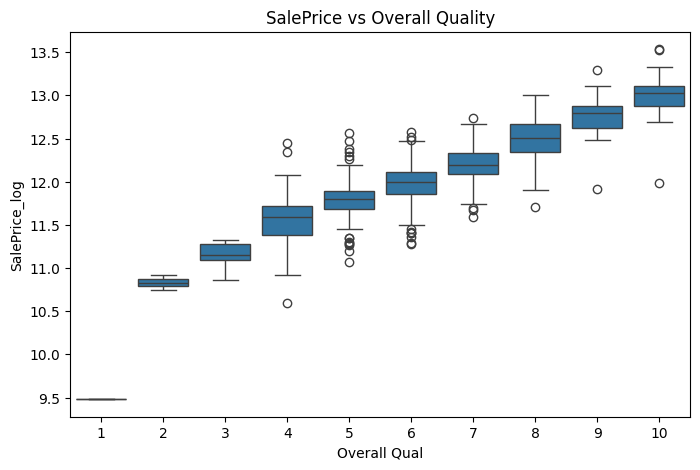

In [92]:
#Boxplot to see the relationship between 'Overall Qual' and the log-transformed 'SalePrice_log'
plt.figure(figsize=(8, 5))
sns.boxplot(x='Overall Qual', y='SalePrice_log', data=df)
plt.title('SalePrice vs Overall Quality')
plt.show()

- The boxplot reveals a strong monotonic relationship between `Overall Qual` and the log-transformed sale price. As overall quality increases, both the median and spread of house prices increase significantly, confirming that overall quality is a key predictor of house prices.

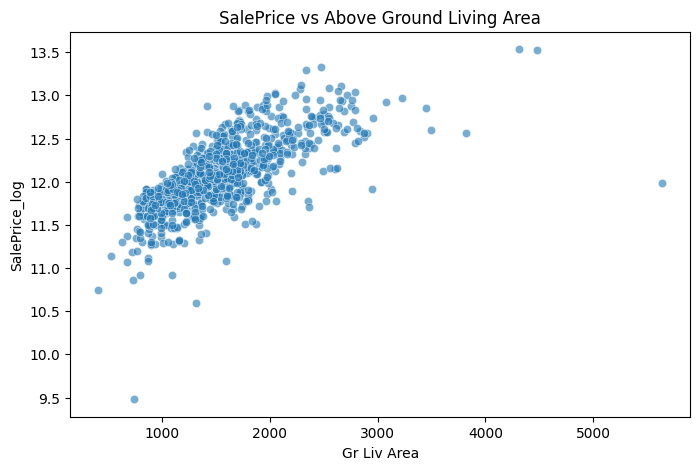

In [93]:
#Scatter plot to see the relationship between 'Gr Liv Area' and the log-transformed 'SalePrice_log'
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Gr Liv Area', y='SalePrice_log', data=df, alpha=0.6)
plt.title('SalePrice vs Above Ground Living Area')
plt.show()

In [94]:
# Identifying and dropping extreme outliers
outliers = df[df['Gr Liv Area'] > 4000].index
df = df.drop(outliers, axis=0)

# Quick check to see the new max
print(f"New maximum Living Area: {df['Gr Liv Area'].max()}")

New maximum Living Area: 3820


- Upon visualizing `Gr Liv Area` against `SalePrice_log`, we identified extreme outliers with very high living area (> 4,000 sq ft) but disproportionately low sale prices. These observations deviate from the general market trend and can negatively impact the model's ability to generalize. We removed these rows to ensure a more robust linear relationship.

### Correlation Analysis

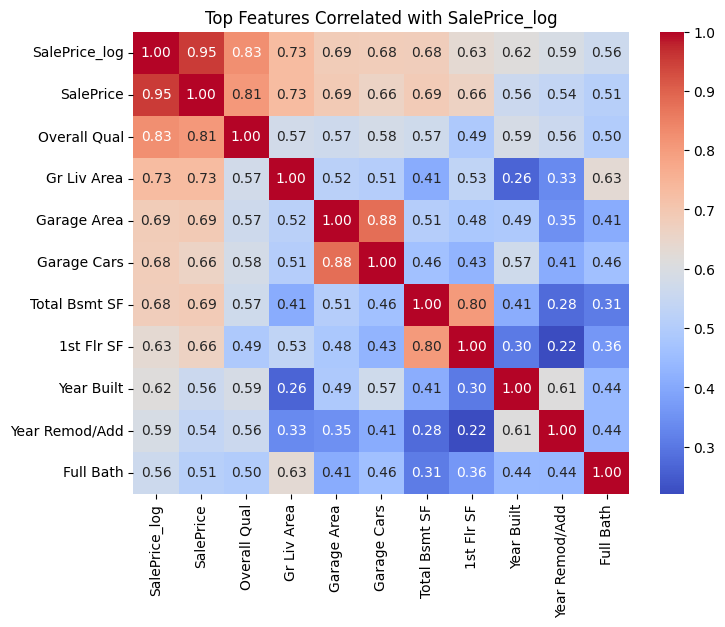

In [95]:
# 1. Calculate correlations
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Get the top 10 features most correlated with SalePrice_log
top_corr_features = corr_matrix['SalePrice_log'].sort_values(ascending=False).head(11).index

# 3. Plot only those features
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Features Correlated with SalePrice_log')
plt.show()

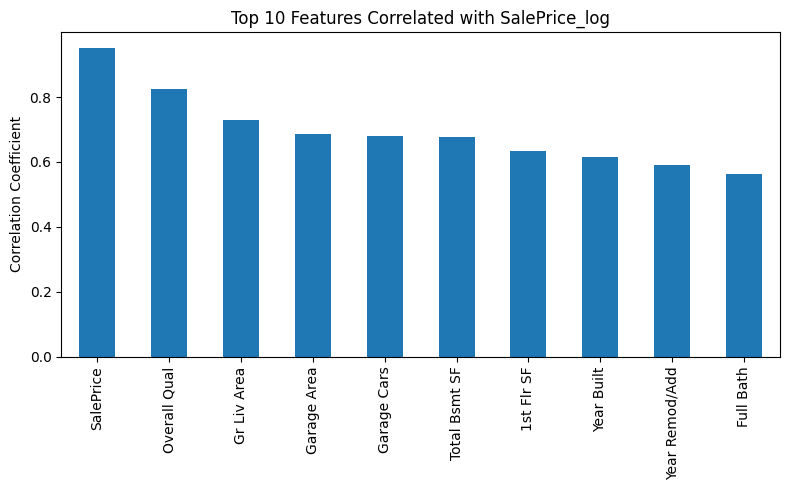

In [96]:
#Get only numeric columns
numeric_df = df.select_dtypes(include=['number'])

#Top 10 correlations with SalePrice_log
top_corr = (
    numeric_df.corr()['SalePrice_log']
    .drop('SalePrice_log')
    .sort_values(ascending=False)
    .head(10)
)

#Plotting the top 10 correlated features
plt.figure(figsize=(8, 5))
top_corr.plot(kind='bar')
plt.title('Top 10 Features Correlated with SalePrice_log')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

**Correlation Analysis Summary:**

- `Overall Qual` shows the strongest positive correlation with house prices.
- Living space features (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`) are major price drivers.
- Garage capacity (`Garage Cars`, `Garage Area`) has a noticeable impact.
- Newer houses (`Year Built`) tend to sell for higher prices.

These results confirm that **quality, size, and amenities** are the primary factors influencing house prices.

In [97]:
#Top 10 and Bottom 10 neighborhoods by median SalePrice
neighborhood_prices = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
)

top_bottom = pd.concat([neighborhood_prices.head(10), neighborhood_prices.tail(10)])

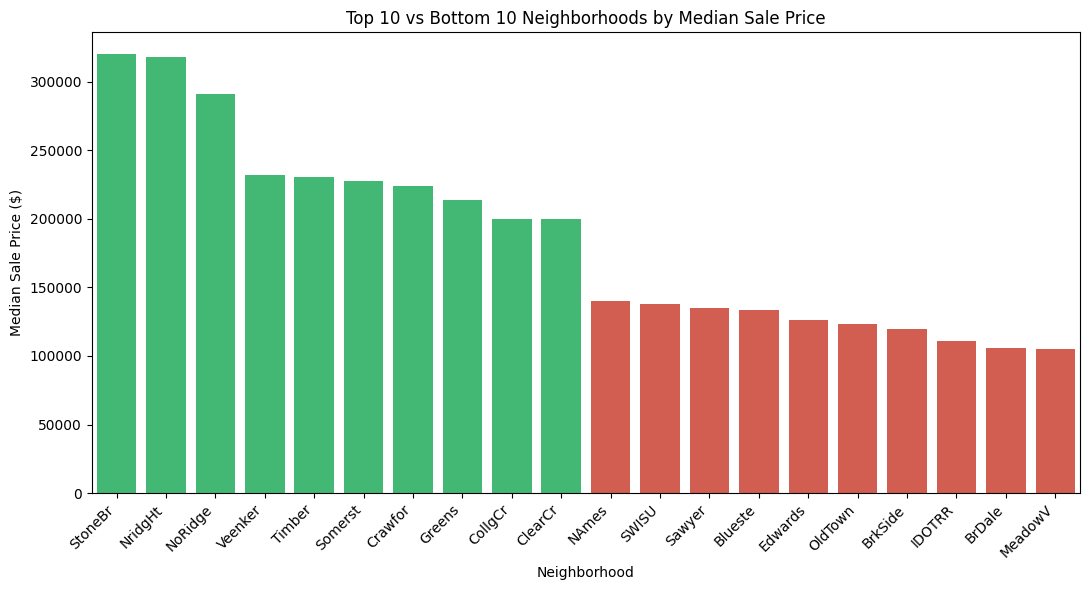

In [98]:
#Bar plot to compare the top 10 and bottom 10 neighborhoods
plt.figure(figsize=(11, 6))
colors = ['#2ecc71'] * 10 + ['#e74c3c'] * 10  #Green for top, red for bottom
sns.barplot(x = top_bottom.index, y = top_bottom.values, palette=colors)
plt.title('Top 10 vs Bottom 10 Neighborhoods by Median Sale Price')
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price ($)')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

- The chart highlights the **most and least expensive neighborhoods** in the dataset.
  Top-tier areas like `StoneBr`, `NridgHt`, and `NoRidge` command median prices well above 
  the dataset average (~$192k), while lower-end neighborhoods like `MeadowV` and `BrDale` 
  fall significantly below it.
- The price gap between the best and worst neighborhoods is substantial (~3×), confirming 
  that **location is one of the strongest drivers of sale price** (even more so than many 
  physical house features).
- This finding suggests that `Neighborhood` should be encoded and included as a feature 
  in the predictive model.

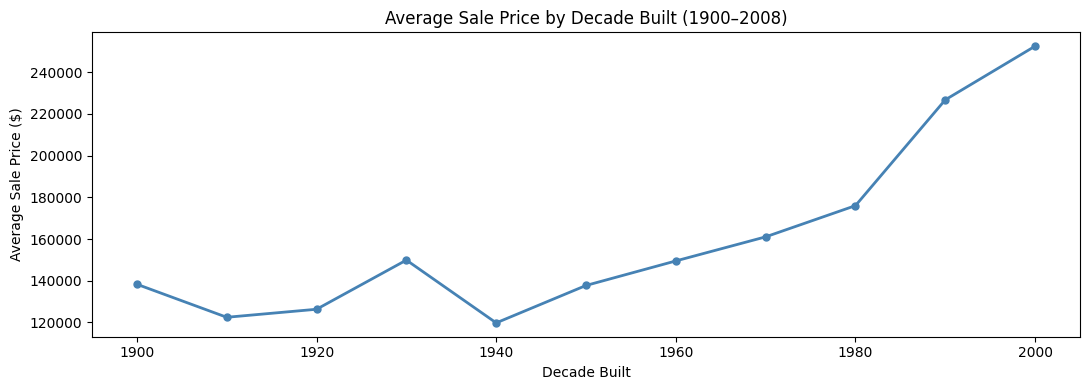

In [99]:
#Average Sale Price by Decade Built (1900–2008)
df_filtered = df[df['Year Built'] >= 1900]
df_filtered['Decade Built'] = (df_filtered['Year Built'] // 10) * 10

avg_price_by_decade = df_filtered.groupby('Decade Built')['SalePrice'].mean()

#Line plot to show the trend of average sale price by decade built
plt.figure(figsize=(11, 4))
plt.plot(avg_price_by_decade.index, avg_price_by_decade.values, 
         color='steelblue', linewidth=2, marker='o', markersize=5)
plt.title('Average Sale Price by Decade Built (1900–2008)')
plt.xlabel('Decade Built')
plt.ylabel('Average Sale Price ($)')
plt.tight_layout()
plt.show()

- Houses built more recently consistently command higher sale prices, with properties 
  from the **2000s** reaching the highest average prices in the dataset (~$250k).
- There is a notable dip around the **1940s**, likely reflecting WWII-era construction 
  which prioritized utility over quality, resulting in lower market valuations today.
- The sharp acceleration in prices from **1980 onwards** reflects the shift toward 
  modern construction standards, better insulation, open floor plans, and updated amenities.
- This confirms that `Year Built` is a meaningful predictor and should be included in 
  the predictive model.

## Final EDA Conclusion

Exploratory data analysis of the Housing dataset shows that house prices are primarily driven by **overall quality, living space, and amenities**. The target variable `SalePrice` was positively skewed, and applying a log transformation improved its distribution for modeling. Strong positive relationships were observed between `SalePrice` and features such as `Overall Qual`, `Gr Liv Area`, `Total Bsmt SF`, and garage-related attributes. Additionally, neighborhood analysis revealed a ~3× price gap between the most and least expensive areas, confirming location as one of the strongest pricing factors. A decade-level trend analysis further showed that newer construction consistently commands higher prices, with a notable dip in 1940s-era housing and a sharp price acceleration from the 1980s onwards. Outliers with unusually large living areas and low sale prices were removed to strengthen linear relationships. Overall, the dataset demonstrates clear and interpretable patterns, making it well-suited for predictive modeling.

## Additional Considerations

### Handling Large Datasets
The dataset was processed efficiently using pandas by working only with relevant columns when needed (for example numeric features for correlation analysis). Visualizations were limited to the most informative features to reduce computational overhead and maintain clarity. This approach ensures scalability when working with larger housing datasets.

### Communication for Non-Technical Stakeholders
The key insights were communicated through clear visualizations (histograms, boxplots, and bar charts) and simple interpretations. Technical metrics such as correlation were converted into intuitive explanations, focusing on practical factors like house size, quality, and amenities rather than statistical terminology. The neighborhood comparison and decade-level price trend charts were designed to be especially intuitive for non-technical audiences, translating complex pricing patterns into clear visual narratives without requiring statistical background.

### Innovative Methods and Techniques
Several data-driven techniques were used to ensure high data quality and analysis precision. We used Domain-Specific Imputation by replacing missing categorical values with "None" and numerical gaps with 0 based on feature types rather than using a simple global mean. A log transformation of the target variable was implemented to address positive skewness and stabilize variance. Additionally, correlation-based feature selection allowed us to focus on the most impactful variables, while strategic outlier detection—specifically removing houses over 4,000 sq ft with unusually low prices—was used to improve model robustness and ensure findings reflect typical market trends.  Neighborhood-level aggregation and decade-based binning of construction year were applied to uncover macro-level pricing patterns that would be hidden in raw feature-level analysis. These steps collectively enhance both the interpretability and predictive performance of the final analysis.